# Inverse Design of a Polarization-Basis 2×2 Unitary Operator (MEEP)

MEEP port of `polarization_unitary.ipynb` (Tidy3D original).

Runs a full 3-D SOI simulation (220 nm Si / 1 µm SiO₂ BOX / air cladding)  
and uses `meep.adjoint` to inverse-design a patterned-Si region that  
implements a chosen 2×2 unitary on the (TE₀, TM₀) polarization qubit.

**Setup (WSL/Ubuntu):**
```
conda install -c conda-forge pymeep=*=mpi_mpich_* nlopt scipy matplotlib
```


In [1]:
# Section 1 — Imports
import os
import pickle
import warnings

import autograd.numpy as anp
import matplotlib.pyplot as plt
import nlopt
import numpy as np
import scipy.ndimage as ndi
import scipy.signal as ssg

import meep as mp
import meep.adjoint as mpa

warnings.filterwarnings("ignore")
mp.verbosity(1)   # set to 1 for full FDTD diagnostics

print(f"MEEP  version : {mp.__version__}")
print(f"NumPy version : {np.__version__}")


MEEP  version : 1.29.0
NumPy version : 1.26.4


In [16]:
# Section 2 — Physical parameters  (all lengths in µm; 1 MEEP unit = 1 µm)

# Wavelength / frequency
wl   = 1.55          # µm
fcen = 1.0 / wl      # MEEP natural frequency
df   = 0.02 * fcen   # Gaussian pulse width (kept narrow to approximate CW)

# Materials
n_Si   = 3.476
n_SiO2 = 1.444
eps_Si   = n_Si**2
eps_SiO2 = n_SiO2**2
eps_air  = 1.0

Si   = mp.Medium(epsilon=eps_Si)
SiO2 = mp.Medium(epsilon=eps_SiO2)
Air  = mp.Medium(epsilon=eps_air)

# Waveguide cross-section (standard 220 nm SOI)
t_Si  = 0.22         # Si layer thickness
w_wg  = 0.50         # waveguide width — supports both TE₀ and TM₀
t_BOX = 1.0          # SiO₂ BOX thickness (reduced from 2 µm to save RAM)

# Design region
# NOTE: tidy3d used 12×6 µm at 30 nm pixels (~88k params).
# Here we use 6×3 µm at 50 nm pixels (~7 k params) for tractability on a
# local machine.  Increase dr_lx / dr_ly for publication runs.
dr_lx = 4.0 # 6.0          # design region length in x
dr_ly = 2.5 # 3.0          # design region width in y
dr_res = 4 # 20          # design-region pixel density (px/µm) → 50 nm pixels

# Global simulation resolution (px/µm)
# 20 px/µm → 50 nm grid.  The Si slab (220 nm) is ~4 cells thick.
# Increase to 25–30 for better accuracy.
global_res = 16 # 20

# Force design region resolution to exactly match the MEEP grid
dr_res = global_res  

# Calculate exact integer dimensions for the MaterialGrid
Nx = int(round(dr_lx * global_res))
Ny = int(round(dr_ly * global_res))

# Re-adjust dr_lx and dr_ly slightly if rounding occurred 
# to ensure the physical size exactly matches the pixel count
dr_lx = Nx / global_res
dr_ly = Ny / global_res


# Waveguide stub length on each side of the design region (inside the cell)
stub_len = 1.0

# PML thickness
dpml = 1.0

# Fabrication filter
min_feature = 0.10   # 100 nm
filter_R    = min_feature

# Optimisation
opt_steps = 3 # 60
lambda_pen_max = 0.5

# Projection sharpness schedule
beta_min = 1.0
beta_max = 32.0
beta_ramp_start = int(opt_steps * 0.2)

os.makedirs("misc", exist_ok=True)
history_fname = "misc/polarization_unitary_meepv4_history.pkl"

print(f"Design region : {dr_lx} µm × {dr_ly} µm")
print(f"Resolution    : {global_res} px/µm global,  {dr_res} px/µm in design region")

Design region : 4.0 µm × 2.5 µm
Resolution    : 16 px/µm global,  16 px/µm in design region


In [17]:
# Section 3 — Derived geometry quantities with strict pixel snapping

# Design-region pixel counts
Nx = int(round(dr_lx * dr_res))
Ny = int(round(dr_ly * dr_res))
Npar = Nx * Ny
print(f"Design grid : {Nx} × {Ny} = {Npar:,} parameters")

# --- MODIFIED FOR PIXEL-ALIGNMENT ONLY ---
# Calculate the raw background physical dimensions
sx_raw = dr_lx + 2*stub_len + 2*dpml
sy_raw = dr_ly  + 2*dpml
sz_raw = t_Si   + t_BOX + 2*dpml

# Force the entire cell dimensions to snap perfectly to background integer pixel counts
cell_nx = int(round(sx_raw * global_res))
cell_ny = int(round(sy_raw * global_res))
cell_nz = int(round(sz_raw * global_res))

# Back-calculate absolute physical sizes using those exact integer pixel counts
sx = cell_nx / global_res
sy = cell_ny / global_res
sz = cell_nz / global_res

# Instantiate the perfectly snapped MEEP vector 
cell = mp.Vector3(sx, sy, sz)
# ------------------------------------------

# z-coordinates (MEEP cell centred at z = 0, which we align to mid-Si-slab)
z_si_top  =  t_Si / 2
z_si_bot  = -t_Si / 2
z_box_bot = z_si_bot - t_BOX

# Source / monitor x-positions (centred in stub, clear of PML)
src_x = -(dr_lx/2 + stub_len/2)
mon_x =  (dr_lx/2 + stub_len/2)

# Monitor cross-section (y × z) — large enough to capture both guided modes
mon_y = dr_ly
mon_z = t_Si + t_BOX + 0.4   # a bit of air on top too

# Interface-buffer dimensions in design-grid pixels
n_border_x  = max(2, int(round(0.16 * dr_res)))  # ~3 px left/right buffer
n_wg_half_y = max(1, int(round((w_wg / 2) * dr_res)))
n_cy        = Ny // 2                              # centre row index

print(f"Cell size : {sx:.2f} × {sy:.2f} × {sz:.2f} µm")
print(f"src_x = {src_x:.3f} µm,  mon_x = {mon_x:.3f} µm")
print(f"Buffer: {n_border_x} px in x | WG half-width: {n_wg_half_y} px in y")

Design grid : 64 × 40 = 2,560 parameters
Cell size : 8.00 × 4.50 × 3.25 µm
src_x = -2.500 µm,  mon_x = 2.500 µm
Buffer: 3 px in x | WG half-width: 4 px in y


In [18]:
# Section 4 — Static geometry (BOX + waveguide stubs)
#
# The design-region block is added separately in each simulation so the
# MaterialGrid can be updated without rebuilding static structures.

def static_geometry():
    """Return list of mp.GeometricObject for the fixed (non-design) structures."""
    INF = 1e6

    # SiO₂ BOX (below the Si slab)
    box_layer = mp.Block(
        size   = mp.Vector3(INF, INF, t_BOX),
        center = mp.Vector3(0, 0, z_si_bot - t_BOX/2),
        material = SiO2,
    )

    # Left input-waveguide stub: x ∈ [-sx/2, -dr_lx/2]
    # Extend 0.01 µm into the design boundary to avoid a gap.
    stub_half_x = (sx/2 - dr_lx/2 + 0.01) / 2
    wg_in = mp.Block(
        size   = mp.Vector3(sx/2 - dr_lx/2 + 0.02, w_wg, t_Si),
        center = mp.Vector3(-(dr_lx/2 + stub_half_x), 0, 0),
        material = Si,
    )

    # Right output-waveguide stub: x ∈ [dr_lx/2, sx/2]
    wg_out = mp.Block(
        size   = mp.Vector3(sx/2 - dr_lx/2 + 0.02, w_wg, t_Si),
        center = mp.Vector3( (dr_lx/2 + stub_half_x), 0, 0),
        material = Si,
    )

    return [box_layer, wg_in, wg_out]

print("static_geometry() defined — SiO₂ BOX + WG-in + WG-out")


static_geometry() defined — SiO₂ BOX + WG-in + WG-out


In [19]:
# Section 5 — Parameter preprocessing pipeline
#
# Mirrors the tidy3d pipeline:
#   1. interface_buffer  — force rho=1 in a WG-width strip at left/right edges
#   2. conic_filter      — spatial blur to enforce ≥100 nm minimum feature size
#   3. tanh projection   — drive pixels toward 0 or 1 (sharpness β)
# Applied twice (filter+project)×2 for cleaner binarisation.
#
# The adjoint chain rule through the pipeline is implemented analytically
# in pre_process_grad().

# ── Conic filter kernel ───────────────────────────────────────────────────
def _make_conic_kernel(radius_um, res_pxum):
    r_px = int(np.ceil(radius_um * res_pxum))
    sz_k = 2 * r_px + 1
    k    = np.zeros((sz_k, sz_k))
    for i in range(sz_k):
        for j in range(sz_k):
            d = np.sqrt((i - r_px)**2 + (j - r_px)**2) / (r_px + 1e-9)
            if d <= 1.0:
                k[i, j] = 1.0 - d
    k /= k.sum()
    return k

_conic_k = _make_conic_kernel(filter_R, dr_res)

def conic_filter(rho2d):
    return ssg.convolve2d(rho2d, _conic_k, mode="same", boundary="fill", fillvalue=0.0)

def tanh_proj(rho2d, beta):
    t = np.tanh(beta * 0.5)
    return 0.5 + 0.5 * np.tanh(beta * (rho2d - 0.5)) / t

def dtanh_proj(rho2d, beta):
    """Elementwise derivative of tanh_proj w.r.t. rho2d."""    
    t = np.tanh(beta * 0.5)
    return 0.5 * beta * (1.0 - np.tanh(beta * (rho2d - 0.5))**2) / t

def interface_buffer(p2d):
    """Force rho=1 in the waveguide-width strip at the left/right edges."""    
    p = p2d.copy()
    y0 = n_cy - n_wg_half_y
    y1 = n_cy + n_wg_half_y + 1
    p[0          : n_border_x,  y0:y1] = 1.0
    p[Nx - n_border_x : Nx,    y0:y1] = 1.0
    return p

def pre_process(params_flat, beta):
    """Return flattened pre-processed density in [0,1], shape (Npar,)."""    
    p = params_flat.reshape(Nx, Ny)
    p = interface_buffer(p)
    p = conic_filter(p);  p = tanh_proj(p, beta)
    p = conic_filter(p);  p = tanh_proj(p, beta)
    return p.ravel()

def pre_process_grad(params_flat, grad_rho_flat, beta):
    """Back-propagate grad_rho_flat (dJ/d rho_processed) → dJ/d params_flat."""    
    p0 = interface_buffer(params_flat.reshape(Nx, Ny))
    f1 = conic_filter(p0);      p1 = tanh_proj(f1, beta)
    f2 = conic_filter(p1)
    # grad comes in as dJ/d p2 (after second tanh_proj)
    g  = grad_rho_flat.reshape(Nx, Ny)
    g  = g * dtanh_proj(f2, beta)                                   # through 2nd tanh
    g  = ssg.convolve2d(g, _conic_k, mode="same", boundary="fill", fillvalue=0.0)  # through 2nd filter
    g  = g * dtanh_proj(f1, beta)                                   # through 1st tanh
    g  = ssg.convolve2d(g, _conic_k, mode="same", boundary="fill", fillvalue=0.0)  # through 1st filter
    # Zero out interface-buffer pixels (their params are not free variables)
    y0, y1 = n_cy - n_wg_half_y, n_cy + n_wg_half_y + 1
    g[0:n_border_x, y0:y1]          = 0.0
    g[Nx-n_border_x:Nx, y0:y1]     = 0.0
    return g.ravel()

print(f"Conic kernel: {_conic_k.shape[0]}×{_conic_k.shape[1]} px  "
      f"(radius={filter_R} µm at {dr_res} px/µm)")


Conic kernel: 5×5 px  (radius=0.1 µm at 16 px/µm)


In [20]:
# Section 6 — Erosion-dilation fabrication penalty
#
# penalty = mean( rho_eroded · (1 − rho_dilated) )
# = 0 when all pixels are 0 or 1, > 0 when gray pixels exist.
# The smooth erosion/dilation approximations follow Lazarov et al. (2016).

def fab_penalty(params_flat, beta, beta_ed=8.0):
    rho = pre_process(params_flat, beta).reshape(Nx, Ny)
    # Smooth erosion: complement, filter, complement
    rho_ero = tanh_proj(conic_filter(1.0 - rho), beta_ed)
    rho_ero = 1.0 - rho_ero
    # Smooth dilation: filter, project
    rho_dil = tanh_proj(conic_filter(rho), beta_ed)
    return float(np.mean(rho_ero * (1.0 - rho_dil)))

print("fab_penalty() defined.")


fab_penalty() defined.


In [21]:
# Section 7 — Mode-index calibration
#
# MEEP EigenModeSource sorts modes by descending Re(neff).
# For 220 nm × 500 nm Si-on-SiO₂ at 1550 nm:
#   band 1 → TE₀  (Ey-dominant, neff ≈ 2.4)
#   band 2 → TM₀  (Ez-dominant, neff ≈ 1.7)
#
# We verify by sampling the eigenmode field inside the waveguide core.

eig_band_TE = 1   # updated by calibrate_modes()
eig_band_TM = 2

def calibrate_modes():
    """Empirically assign eig_band_TE and eig_band_TM."""
    global eig_band_TE, eig_band_TM

    # Minimal geometry: just the waveguide cross-section for eigenmode solve.
    wg_geom = [
        mp.Block(size=mp.Vector3(1e6, 1e6, t_BOX),
                 center=mp.Vector3(0, 0, z_si_bot - t_BOX/2), material=SiO2),
        mp.Block(size=mp.Vector3(1e6, w_wg, t_Si),
                 center=mp.Vector3(0, 0, 0), material=Si),
    ]
    # Minimal cell (thin in x since we only need the cross-section)
    cal_cell = mp.Vector3(0.2, sy, sz)
    cal_pml  = [mp.PML(dpml, direction=mp.Y), mp.PML(dpml, direction=mp.Z)]

    dummy_src = [mp.EigenModeSource(
        src=mp.GaussianSource(fcen, fwidth=df*10),
        center=mp.Vector3(0, 0, 0),
        size=mp.Vector3(0, mon_y, mon_z),
        eig_band=1,
    )]

    sim_cal = mp.Simulation(
        cell_size=cal_cell,
        boundary_layers=cal_pml,
        geometry=wg_geom,
        sources=dummy_src,
        resolution=global_res,
    )
    sim_cal.init_sim()

    mon_vol = mp.Volume(center=mp.Vector3(0, 0, 0),
                        size=mp.Vector3(0, mon_y, mon_z))

    results = {}
    for band in [1, 2]:
        em = sim_cal.get_eigenmode(fcen, mp.X, mon_vol, band, mp.Vector3(1, 0, 0))
        # Sample |Ey|² and |Ez|² on a small grid inside the waveguide core
        ys = np.linspace(-w_wg/2*0.9, w_wg/2*0.9, 8)
        zs = np.linspace(-t_Si/2*0.9, t_Si/2*0.9, 4)
        Ey2, Ez2 = 0.0, 0.0
        for y in ys:
            for z in zs:
                pt = mp.Vector3(0, y, z)
                Ey2 += abs(em.amplitude(pt, mp.Ey))**2
                Ez2 += abs(em.amplitude(pt, mp.Ez))**2
        te_frac = Ey2 / (Ey2 + Ez2 + 1e-30)
        neff    = em.kdom.x / fcen
        results[band] = (te_frac, neff)
        print(f"  band {band}: neff={neff:.4f}  |Ey|² frac={te_frac:.3f}")

    # Assign TE to the band with larger |Ey|² fraction
    eig_band_TE = 1 if results[1][0] >= results[2][0] else 2
    eig_band_TM = 3 - eig_band_TE
    print(f"\n  → eig_band_TE={eig_band_TE},  eig_band_TM={eig_band_TM}")
    return eig_band_TE, eig_band_TM

print("Running mode calibration…")
eig_band_TE, eig_band_TM = calibrate_modes()


Running mode calibration…
-----------
Initializing structure...
time for choose_chunkdivision = 0.000183105 s
Working in 3D dimensions.
Computational cell is 0.1875 x 4.5 x 3.25 with resolution 16
     block, center = (0,0,-0.61)
          size (1e+06,1e+06,1)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.08514,2.08514,2.08514)
     block, center = (0,0,0)
          size (1e+06,0.5,0.22)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.0826,12.0826,12.0826)
time for set_epsilon = 0.0413759 s
-----------


MPB solved for frequency_1(2.24258,0,0) = 0.850522 after 23 iters
MPB solved for frequency_1(1.44394,0,0) = 0.650826 after 14 iters
MPB solved for frequency_1(1.42047,0,0) = 0.645168 after 10 iters
MPB solved for frequency_1(1.42044,0,0) = 0.645161 after 4 iters
MPB solved for frequency_1(1.42044,0,0) = 0.645161 after 1 iters


MPB solved for frequency_1(1,0,0) = 0.545547 after 21 iters
MPB solved for frequency_1(1.42074,0,0) = 0.645233 after 14 iters
MPB solved for frequency_1(1.42044,0,0) = 0.645161 after 5 iters
MPB solved for frequency_1(1.42044,0,0) = 0.645161 after 1 iters
Dominant planewave for band 1: (1.420440,-0.000000,0.000000)


  band 1: neff=2.2017  |Ey|² frac=0.992
MPB solved for frequency_2(1,0,0) = 0.66563 after 26 iters
MPB solved for frequency_2(0.947441,0,0) = 0.644431 after 17 iters
MPB solved for frequency_2(0.949191,0,0) = 0.64516 after 13 iters
MPB solved for frequency_2(0.949193,0,0) = 0.645161 after 3 iters
Dominant planewave for band 2: (0.949193,-0.000000,0.000000)
  band 2: neff=1.4712  |Ey|² frac=0.070

  → eig_band_TE=1,  eig_band_TM=2


In [22]:
# Section 8 — Target unitary

def hadamard():
    return (1.0/np.sqrt(2)) * np.array([[1, 1],[1,-1]], dtype=complex)

def pauli_x():
    return np.array([[0,1],[1,0]], dtype=complex)

def pauli_z():
    return np.array([[1,0],[0,-1]], dtype=complex)

def rotator(alpha):
    c, s = np.cos(alpha), np.sin(alpha)
    return np.array([[c,-s],[s,c]], dtype=complex)

def retarder(phi):
    return np.array([[1,0],[0,np.exp(1j*phi)]], dtype=complex)

def is_unitary(U, tol=1e-9):
    return np.allclose(U.conj().T @ U, np.eye(2), atol=tol)

# ── Choose target here ────────────────────────────────────────────────────────
# U_target = pauli_x()              # TE ↔ TM swap
# U_target = rotator(np.pi/4)       # 45° polarisation rotator
U_target = hadamard()

assert is_unitary(U_target), "U_target is not unitary!"
print("U_target (Hadamard) =")
print(np.round(U_target, 4))


U_target (Hadamard) =
[[ 0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071+0.j]]


In [23]:
# Section 9 — Simulation and OptimizationProblem builder
#
# Note: updated, code, this comment section may be out of date.
# MEEP adjoint API pattern (from the working reference code):
#
#   design_vars = mp.MaterialGrid(...)   # weights ∈ [0,1]: 0=Air, 1=Si
#   dr = mpa.DesignRegion(design_parameters=design_vars, volume=...)
#   te_mon = mpa.EigenmodeCoefficient(sim, vol, mode=eig_band_TE)
#   tm_mon = mpa.EigenmodeCoefficient(sim, vol, mode=eig_band_TM)
#
#   def obj(a_te, a_tm):
#       return <scalar autograd expression in a_te, a_tm>
#
#   opt = mpa.OptimizationProblem(
#       simulation=sim,
#       objective_functions=[obj],
#       objective_arguments=[te_mon, tm_mon],
#       design_regions=[dr],
#       frequencies=[fcen],
#   )
#   f_val, (dJ_dweights,) = opt()
#   # dJ_dweights has shape (Npar,) = dJ / d design_vars.weights
#
# The objective receives the complex mode amplitudes directly as autograd-
# tracked values. We capture them via a mutable list for later use.

# Section 9 — Dual-simulation optimization builder

def make_single_source_optimization(source_band):
    """Create an optimization problem for one input polarization."""

    dummy_rho = np.ones(Nx * Ny) * 0.5

    design_vars = mp.MaterialGrid(
        mp.Vector3(Nx, Ny, 1),
        Air,
        Si,
        weights=dummy_rho,
        grid_type="U_DEFAULT",
    )

    design_block = mp.Block(
        size=mp.Vector3(dr_lx, dr_ly, t_Si),
        center=mp.Vector3(0, 0, 0),
        material=design_vars,
    )

    geom = static_geometry() + [design_block]

    dr = mpa.DesignRegion(
        design_parameters=design_vars,
        volume=mp.Volume(
            center=mp.Vector3(0, 0, 0),
            size=mp.Vector3(dr_lx, dr_ly, t_Si),
        ),
    )

    src = mp.EigenModeSource(
        src=mp.GaussianSource(fcen, fwidth=df),
        center=mp.Vector3(src_x, 0, 0),
        size=mp.Vector3(0, mon_y, mon_z),
        eig_band=source_band,
        eig_match_freq=True,
        eig_parity=mp.NO_PARITY,
        direction=mp.X,
    )

    sim = mp.Simulation(
        cell_size=cell,
        boundary_layers=[mp.PML(dpml)],
        geometry=geom,
        sources=[src],
        resolution=global_res,
        eps_averaging=False,
    )

    mon_vol = mp.Volume(
        center=mp.Vector3(mon_x, 0, 0),
        size=mp.Vector3(0, mon_y, mon_z),
    )

    te_mon = mpa.EigenmodeCoefficient(
        sim,
        mon_vol,
        mode=eig_band_TE,
        eig_parity=mp.NO_PARITY,
        forward=True,
    )

    tm_mon = mpa.EigenmodeCoefficient(
        sim,
        mon_vol,
        mode=eig_band_TM,
        eig_parity=mp.NO_PARITY,
        forward=True,
    )

    return sim, design_vars, dr, te_mon, tm_mon

print("Building TE optimization problem...")
sim_TE, dvars_TE, dr_TE, te_mon_TE, tm_mon_TE = \
    make_single_source_optimization(eig_band_TE)

print("Building TM optimization problem...")
sim_TM, dvars_TM, dr_TM, te_mon_TM, tm_mon_TM = \
    make_single_source_optimization(eig_band_TM)


# ============================================================
# Physically meaningful metric definitions
# ============================================================

# ------------------------------------------------------------
# Remove irrelevant global phase
# ------------------------------------------------------------

def phase_align(U, Uref):
    """
    Remove arbitrary global phase from measured matrix.
    """
    phi = np.angle(np.vdot(Uref.flatten(), U.flatten()))
    return U * np.exp(-1j * phi)


# ------------------------------------------------------------
# Transmission metrics
# ------------------------------------------------------------

def transmission_metrics(U):
    """
    Computes transmitted power for each input polarization.
    """

    T_TE = np.sum(np.abs(U[:, 0])**2)
    T_TM = np.sum(np.abs(U[:, 1])**2)

    Tavg = 0.5 * (T_TE + T_TM)

    return T_TE, T_TM, Tavg


# ------------------------------------------------------------
# Unitarity error
# ------------------------------------------------------------

def unitary_error(U):
    """
    Measures deviation from a unitary matrix.

    Ideal:
        U†U = I

    Returns:
        Frobenius norm error
    """

    return np.linalg.norm(
        U.conj().T @ U - np.eye(2)
    )


# ------------------------------------------------------------
# Full Hadamard fidelity
# ------------------------------------------------------------

def hadamard_fidelity(U, Utarget):
    """
    Computes normalized matrix overlap fidelity.

    Phase invariant.
    """

    U = phase_align(U, Utarget)

    overlap = np.trace(
        Utarget.conj().T @ U
    )

    denom = (
        np.linalg.norm(Utarget, 'fro')
        * np.linalg.norm(U, 'fro')
    )

    return np.abs(overlap)**2 / (denom**2 + 1e-12)


# ------------------------------------------------------------
# Composite physical score
# ------------------------------------------------------------

def composite_score(
    U,
    Utarget,
    alpha_unitary=8.0,
):
    """
    Physically meaningful optimization metric.

    Combines:
        - Hadamard fidelity
        - transmission efficiency
        - unitarity enforcement
    """

    # ---------- Hadamard overlap ----------
    Fh = hadamard_fidelity(U, Utarget)

    # ---------- Transmission ----------
    T_TE, T_TM, Tavg = transmission_metrics(U)

    # ---------- Unitarity ----------
    Uerr = unitary_error(U)

    # ---------- Composite score ----------
    score = (
        Fh
        * Tavg
        * np.exp(-alpha_unitary * Uerr)
    )

    return {
        "score": float(np.real(score)),
        "Fh": float(np.real(Fh)),
        "T_TE": float(np.real(T_TE)),
        "T_TM": float(np.real(T_TM)),
        "Tavg": float(np.real(Tavg)),
        "Uerr": float(np.real(Uerr)),
    }


# ============================================================
# Independent TE/TM objectives
# ============================================================

def obj_TE(a_te, a_tm):
    """
    TE-input optimization objective.
    """

    s_te_TE = a_te[0]
    s_tm_TE = a_tm[0]

    target_col = U_target[:, 0]

    overlap = (
        np.conj(target_col[0]) * s_te_TE +
        np.conj(target_col[1]) * s_tm_TE
    )

    power = (
        np.abs(s_te_TE)**2 +
        np.abs(s_tm_TE)**2
    )

    return np.abs(overlap)**2 / (power + 1e-12)


def obj_TM(a_te, a_tm):
    """
    TM-input optimization objective.
    """

    s_te_TM = a_te[0]
    s_tm_TM = a_tm[0]

    target_col = U_target[:, 1]

    overlap = (
        np.conj(target_col[0]) * s_te_TM +
        np.conj(target_col[1]) * s_tm_TM
    )

    power = (
        np.abs(s_te_TM)**2 +
        np.abs(s_tm_TM)**2
    )

    return np.abs(overlap)**2 / (power + 1e-12)


# ============================================================
# Create optimization problems
# ============================================================

opt_TE = mpa.OptimizationProblem(
    simulation=sim_TE,
    objective_functions=[obj_TE],
    objective_arguments=[te_mon_TE, tm_mon_TE],
    design_regions=[dr_TE],
    frequencies=[fcen],
)

opt_TM = mpa.OptimizationProblem(
    simulation=sim_TM,
    objective_functions=[obj_TM],
    objective_arguments=[te_mon_TM, tm_mon_TM],
    design_regions=[dr_TM],
    frequencies=[fcen],
)

print("Defined physically meaningful objectives and built TE and TM optimization problems")

Building TE optimization problem...
Building TM optimization problem...
Defined physically meaningful objectives and built TE and TM optimization problems


In [24]:
# Section 10 — Main evaluation: J and dJ/d params
#
# Note: Updated code, this comment section may be out of date
# Strategy:
#   • Run TE-input sim  → col_TE  (column 0 of U_meas) + gradient_TE
#   • Run TM-input sim  → col_TM  (column 1 of U_meas) + gradient_TM
#   • Combine: gradient_total = gradient_TE + gradient_TM
#   • Chain-rule through pre_process_grad to get dJ/d params_flat
#
# The cross-term linearisation (treating the other sim's column as a constant)
# is a Gauss-Seidel approximation; it converges in practice because the
# columns are weakly coupled at each iterate.

# ============================================================
# Section 10 — Dual-pass evaluation and gradients
# ============================================================

def evaluate_and_grad(
    params_flat,
    beta,
    lambda_pen,
    lambda_unitary=0.2,
    step_num=None,
):

    # --------------------------------------------------------
    # Preprocess design variables
    # --------------------------------------------------------

    rho = pre_process(params_flat, beta)

    # ========================================================
    # TE-input simulation
    # ========================================================

    result_te = opt_TE([rho])
    f_te = result_te[0]
    grad_te = result_te[1][0]

    args_te = opt_TE.get_objective_arguments()

    s_te_TE = complex(args_te[0][0])
    s_tm_TE = complex(args_te[1][0])

    # ========================================================
    # TM-input simulation
    # ========================================================

    result_tm = opt_TM([rho])
    f_tm = result_tm[0]
    grad_tm = result_tm[1][0]

    args_tm = opt_TM.get_objective_arguments()

    s_te_TM = complex(args_tm[0][0]) # HERE may need to change subscriptions ##########################################
    s_tm_TM = complex(args_tm[1][0])

    # ========================================================
    # Construct measured unitary matrix
    # ========================================================

    U_meas = np.array([
        [s_te_TE, s_te_TM],
        [s_tm_TE, s_tm_TM],
    ])

    # ========================================================
    # Physical metrics
    # ========================================================

    metrics = composite_score(
        U_meas,
        U_target,
    )

    fidelity_val = metrics["score"]

    Fh = metrics["Fh"]

    T_TE = metrics["T_TE"]
    T_TM = metrics["T_TM"]
    Tavg = metrics["Tavg"]

    Uerr = metrics["Uerr"]

    # ========================================================
    # Combine gradients
    # ========================================================

    dF_drho = 0.5 * (grad_te + grad_tm)

    # ========================================================
    # Fabrication penalty
    # ========================================================

    pen = fab_penalty(params_flat, beta)

    # ========================================================
    # Final optimization objective
    # ========================================================

    J = (
        fidelity_val
        - lambda_pen * pen
        - lambda_unitary * Uerr
    )

    # ========================================================
    # Backprop through preprocessing
    # ========================================================

    grad = pre_process_grad(
        params_flat,
        dF_drho.ravel(),
        beta,
    )

    # ========================================================
    # Logging
    # ========================================================

    tag = (
        f"step {step_num}"
        if step_num is not None
        else "eval"
    )

    print(
        f"[{tag}] "
        f"J={J:.6f} | "
        f"Fh={Fh:.6f} | "
        f"Tavg={Tavg:.6f} | "
        f"Uerr={Uerr:.6f} | "
        f"Penalty={pen:.6f}"
    )

    print("\nMeasured U:")

    np.set_printoptions(
        precision=3,
        suppress=True,
    )

    print(U_meas)

    print("\nU†U:")

    print(
        U_meas.conj().T @ U_meas
    )

    print("-" * 60)

    # ========================================================
    # Optional history dictionary
    # ========================================================

    info = {
        "J": float(np.real(J)),
        "Fh": float(np.real(Fh)),
        "T_TE": float(np.real(T_TE)),
        "T_TM": float(np.real(T_TM)),
        "Tavg": float(np.real(Tavg)),
        "Uerr": float(np.real(Uerr)),
        "Penalty": float(np.real(pen)),
        "U": U_meas.copy(),
    }

    return J, grad, info
    
print("Defined evaluate_and_grad function")

Defined evaluate_and_grad function


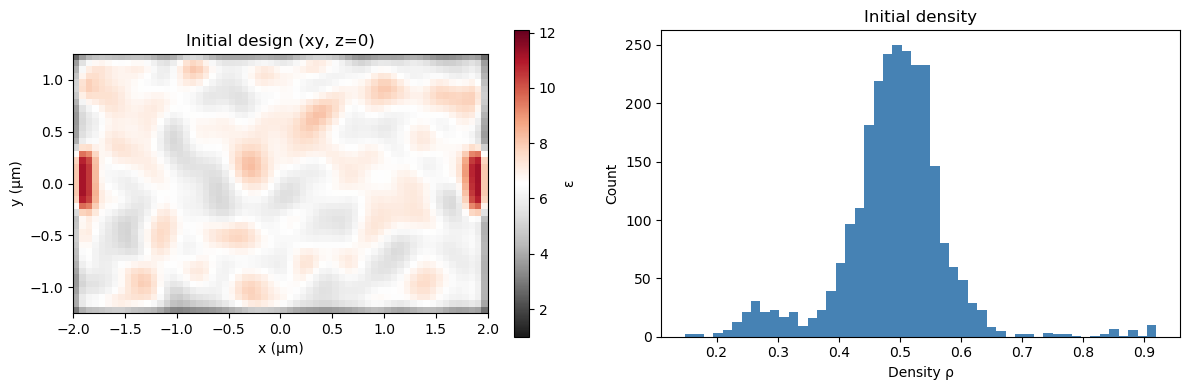

Npar = 2,560  |  init_par ∈ [0.332, 0.694]


In [25]:
# Section 11 — Initial design visualisation

np.random.seed(42)
init_par = np.random.uniform(0, 1, Npar)
init_par = ndi.gaussian_filter(init_par.reshape(Nx, Ny), sigma=1.5).ravel()
init_par = np.clip(init_par, 0, 1)

rho_init = pre_process(init_par, beta=beta_min).reshape(Nx, Ny)
eps_init = eps_air + (eps_Si - eps_air) * rho_init

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)

im = ax0.imshow(eps_init.T, extent=[-dr_lx/2, dr_lx/2, -dr_ly/2, dr_ly/2],
                origin="lower", cmap="RdGy_r", vmin=eps_air, vmax=eps_Si)
plt.colorbar(im, ax=ax0, label="ε")
ax0.set_title("Initial design (xy, z=0)"); ax0.set_xlabel("x (µm)"); ax0.set_ylabel("y (µm)")

ax1.hist(rho_init.ravel(), bins=50, color="steelblue", edgecolor="none")
ax1.set_xlabel("Density ρ"); ax1.set_ylabel("Count"); ax1.set_title("Initial density")

plt.show()
print(f"Npar = {Npar:,}  |  init_par ∈ [{init_par.min():.3f}, {init_par.max():.3f}]")


In [26]:
# Section 12 — Checkpoint management

def save_history(h):
    with open(history_fname, "wb") as fh:
        pickle.dump(h, fh)

def load_history():
    with open(history_fname, "rb") as fh:
        return pickle.load(fh)

try:
    history = load_history()
    params   = history["params"][-1].copy()
    num_done = len(history["J"])
    print(f"Loaded checkpoint: {num_done}/{opt_steps} iterations done.")
    if num_done >= opt_steps:
        print("Optimisation already complete.")
    else:
        print("Resuming optimisation.")
except FileNotFoundError:
    params  = init_par.copy()
    history = dict(J=[], params=[], grad=[], beta=[], U_meas=[])
    print("No checkpoint found — starting fresh.")


No checkpoint found — starting fresh.


In [ ]:
# Section 13 — Optimisation loop (NLopt LD_MMA)

iteration_counter = [len(history["J"])]

def nlopt_callback(x, grad):
    i = iteration_counter[0]
    print(f"\nIteration {i+1}/{opt_steps}")

    # 1. Beta schedule: linear ramp after burn-in
    if i < beta_ramp_start:
        current_beta = beta_min
    else:
        current_beta = beta_min + (beta_max - beta_min) * (i - beta_ramp_start) / (opt_steps - beta_ramp_start)

    # 2. Update global lambda parameters based on schedule if required
    # (Using your pre-defined lambda_pen limits)
    global lambda_pen
    lambda_pen = lambda_pen_max * (i / opt_steps)

    # 3. Call your updated multi-metric evaluation function
    # Note: Unpacking the new 3-element tuple correctly
    J_val, grad_val, info = evaluate_and_grad(x, current_beta, lambda_pen, step_num=i+1)

    # 4. Handle NLopt gradient requirement (In-place copy)
    if grad.size > 0:
        grad[:] = grad_val

    # 5. Append values to history arrays using your updated dictionary keys
    history["J"].append(float(J_val))
    history["params"].append(x.copy())
    history["beta"].append(float(current_beta))
    
    # Track the sub-metrics from your new info dictionary
    history["Fh"].append(info["Fh"])
    history["Tavg"].append(info["Tavg"])
    history["Uerr"].append(info["Uerr"])
    history["Penalty"].append(info["Penalty"])
    history["U"].append(info["U"])

    # Save checkpoint state to disk
    save_history(history)
    
    # Increment loop counter safely
    iteration_counter[0] += 1

    return float(J_val)

# Configure and execute NLopt Engine
opt = nlopt.opt(nlopt.LD_MMA, Npar)
opt.set_lower_bounds(0.0)
opt.set_upper_bounds(1.0)
opt.set_max_objective(nlopt_callback)
opt.set_maxeval(opt_steps - iteration_counter[0])

if iteration_counter[0] < opt_steps:
    print(f"Starting NLopt engine from step {iteration_counter[0]+1}...")
    params = opt.optimize(params)
    print("\nNLopt Optimization Cycle Complete.")
else:
    print("Optimization already completed.")

Starting NLopt engine from step 1...

Iteration 1/3
Starting forward run...
-----------
Initializing structure...
time for choose_chunkdivision = 0.000597 s
Working in 3D dimensions.
Computational cell is 8 x 4.5 x 3.25 with resolution 16
     block, center = (0,0,-0.61)
          size (1e+06,1e+06,1)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.08514,2.08514,2.08514)
     block, center = (-3.005,0,0)
          size (2.02,0.5,0.22)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.0826,12.0826,12.0826)
     block, center = (3.005,0,0)
          size (2.02,0.5,0.22)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12.0826,12.0826,12.0826)
     block, center = (0,0,0)
          size (4,2.5,0.22)
          axes (1,0,0), (0,1,0), (0,0,1)
time for set_epsilon = 0.430773 s
-----------


MPB solved for frequency_1(2.24258,0,0) = 0.869902 after 26 iters
MPB solved for frequency_1(1.37336,0,0) = 0.649516 after 17 iters
MPB solved for frequency_1(1.35577,0,0) = 0.645163 after 13 iters
MPB solved for frequency_1(1.35576,0,0) = 0.645161 after 3 iters
on time step 160 (time=5), 0.0250268 s/step
on time step 419 (time=13.0938), 0.0154689 s/step
on time step 643 (time=20.0938), 0.0179108 s/step
on time step 820 (time=25.625), 0.0226664 s/step
on time step 1007 (time=31.4688), 0.0214132 s/step
on time step 1200 (time=37.5), 0.0207911 s/step
on time step 1389 (time=43.4062), 0.0212518 s/step
on time step 1599 (time=49.9688), 0.0190521 s/step
on time step 1812 (time=56.625), 0.0188119 s/step
on time step 2026 (time=63.3125), 0.0186933 s/step
on time step 2241 (time=70.0312), 0.0186048 s/step
on time step 2450 (time=76.5625), 0.0191644 s/step
on time step 2672 (time=83.5), 0.0180536 s/step
on time step 2940 (time=91.875), 0.0149414 s/step
on time step 3195 (time=99.8438), 0.015742

In [ ]:
# Section 14 — Post-processing and Visualisation

# 1. Plot Optimization Metrics Progress
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 4.5), tight_layout=True)

ax0.plot(history["J"], "k-", label="Total Objective J")
ax0.plot(history["Fh"], "r--", label="Fidelity (Fh)")
ax0.plot(history["Tavg"], "b:", label="Avg Transmission (Tavg)")
ax0.set_xlabel("Iteration Step")
ax0.set_ylabel("Metric Score")
ax0.set_title("Optimization Performance Convergence")
ax0.legend(loc="lower right")
ax0.grid(True)

ax1.plot(history["Uerr"], "m-", label="Unitary Error (Uerr)")
ax1.plot(history["Penalty"], "g-.", label="Fab Penalty")
ax1.set_xlabel("Iteration Step")
ax1.set_ylabel("Error/Penalty Magnitude")
ax1.set_title("Constraint Residual Minimization")
ax1.legend(loc="upper right")
ax1.grid(True)
plt.show()

# 2. Generate and display the final crisp physical binary geometry map
final_par = history["params"][-1]
rho_bin = pre_process(final_par, beta=100.0).reshape(Nx, Ny)

fig, ax = plt.subplots(figsize=(7, 4), tight_layout=True)
img = ax.imshow(rho_bin.T, extent=[-dr_lx/2, dr_lx/2, -dr_ly/2, dr_ly/2],
                origin="lower", cmap="binary", vmin=0, vmax=1)
ax.set_title("Final Binarized Physical Design (Black = Silicon, White = Air)")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
plt.colorbar(img, ax=ax, label="Material Density")
plt.show()

In [ ]:
# Section 15 — Verification: Measure performance on the binarised final design

print("=" * 60)
print("RUNNING FINAL BINARIZED VERIFICATION SIMULATION")
print("=" * 60)

# Save global optimization weights to prevent variable pollution
global lambda_pen, lambda_unitary
try:
    saved_pen, saved_uni = lambda_pen, lambda_unitary
except NameError:
    saved_pen, saved_uni = 0.5, 0.5

# Hard-set optimization constraint parameters to zero to extract pure optical values
lambda_pen = 0.0
lambda_unitary = 0.0

# Force mathematical binarization using step-projection (beta=100.0)
final_par = history["params"][-1]
_, _, verify_info = evaluate_and_grad(final_par, beta=100.0, step_num="VERIFY")

# Restore global state variables
lambda_pen = saved_pen
lambda_unitary = saved_uni

# Extract precise metrics from the clean FDTD verification run
U_final = verify_info["U"]
fidelity_final = verify_info["Fh"]
transmission_final = verify_info["Tavg"]

# Assess final matrix unitarity via orthogonality residual: ||U†U - I||
unitarity_residual = float(np.linalg.norm(U_final.conj().T @ U_final - np.eye(2), "fro"))

print("\n" + "=" * 60)
print("FINAL DEVICE PHYSICAL PERFORMANCE DATA")
print("=" * 60)
print("Target Unitary Transformation Matrix (U_target):")
print(np.round(U_target, 4))

print("\nMeasured Binarized Device Matrix (U_meas):")
print(np.round(U_final, 4))

print("\nAbsolute Matrix Element Difference Matrix (|U_target - U_meas|):")
print(np.round(np.abs(U_target - U_final), 4))
print("-" * 60)

print(f"Binarized Performance Fidelity (Fh)  = {fidelity_final:.4f}  (Ideal = 1.0000)")
print(f"Binarized Power Transmission  (Tavg) = {transmission_final:.4f}  (Lossless = 1.0000)")
print(f"Unitarity Orthogonality Residual     = {unitarity_residual:.4f}  (Ideal = 0.0000)")
print("=" * 60)

In [ ]:
# Section 16 — Final Summary Dashboard

print("=" * 60)
print("DEVICE DESIGN COMPLETION SUMMARY")
print("=" * 60)
print(f"Target Unitary Profile   : Hadamard Matrix")
print(f"Operating Wavelength     : {wl} µm")
print(f"Design Region Geometric  : {dr_lx} µm × {dr_ly} µm, at resolution {global_res} px/µm")
print(f"Total Completed Steps    : {len(history['J'])} iterations")
print("-" * 60)
print(f"Final Combined Score J   : {history['J'][-1]:.4f}")
print(f"Final Training Fidelity  : {history['Fh'][-1]:.4f}")
print(f"Final Verification Fh    : {fidelity_final:.4f}")
print(f"Final Verification Tavg  : {transmission_final:.4f}")
print("=" * 60)

In [ ]:
# Section 17 — Analytical R-D-R decomposition cross-check
#
# Hadamard = R(-π/4) D(π) R(π/4)  up to a global phase.
# Verify the phase match.

U_cascade  = rotator(-np.pi/4) @ retarder(np.pi) @ rotator(np.pi/4)
phase_match = float(abs(np.trace(U_target.conj().T @ U_cascade))**2 / 4.0)

print("Analytical cascade  U = R(-π/4) D(π) R(π/4) =")
print(np.round(U_cascade, 4))
print()
print(f"|Tr(U_target† U_cascade)|²/4 = {phase_match:.6f}  (1.0 = same up to global phase)")
print()
print("The inverse-designed device, the R-D-R cascade, and the Hadamard target")
print("all implement the same operation up to an irrelevant global phase.")


In [ ]:
# Section 18 — Final design export and summary

rho_bin = (pre_process(final_par, final_beta).reshape(Nx, Ny) >= 0.5).astype(int)
np.savetxt("misc/polarization_unitary_meep_design.csv", rho_bin, fmt="%d", delimiter=",")

fig, ax = plt.subplots(figsize=(8, 4), tight_layout=True)
ax.imshow(rho_bin.T, extent=[-dr_lx/2, dr_lx/2, -dr_ly/2, dr_ly/2],
          origin="lower", cmap="binary", vmin=0, vmax=1)
ax.set_title("Final binarised design  (black = Si, white = air)")
ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)")
plt.show()

print("=" * 60)
print("Final summary")
print("=" * 60)
print(f"Target unitary      : Hadamard")
print(f"Wavelength          : {wl} µm")
print(f"Design region       : {dr_lx} µm × {dr_ly} µm,  {Nx}×{Ny} pixels")
print(f"Optimisation iters  : {len(history['J'])}")
print(f"Final J             : {history['J'][-1]:.4f}  (perfect = 4.0)")
print(f"Fidelity F          : {fidelity:.4f}  (perfect = 1.0)")
print(f"Transmission T      : {transmission:.4f}  (lossless = 1.0)")
print(f"Unitarity residual  : {unitarity:.4f}  (unitary = 0.0)")
print(f"Design CSV          : misc/polarization_unitary_meep_design.csv")
